# 02.1 - RAC Evaluation (No Alpha Sweep)

## 1. Notebook Goal
Repeat Phase 2 evaluation with fixed alpha values to measure RAC behavior without alpha tuning.

## 2. Experimental Design
- Reuse the same test split and retrieval collections as the tuned notebook.
- Keep RAC variants and metric definitions identical.
- Disable alpha sweep and use fixed local/KDE alpha values.
- Retain k-density and bandwidth checks for controlled sensitivity analysis.
- Save no-alpha artifacts with dedicated filenames.

## 3. Inputs
- dataset/CVPR_2024_dataset_Test/
- dataset_text/test.csv
- chroma_db/ populated image/text collections
- models/ and text_models/ checkpoints

## 4. Outputs
- results/phase2/evaluation_no_alpha_results.json
- results/phase2/metrics_no_alpha_summary.csv
- results/phase2/scoring_variants_no_alpha_predictions.csv
- figures/phase2/ no-alpha plots

## 5. Execution Guide
Run cells sequentially. Compare outputs against Notebook 02 to isolate the effect of alpha tuning.

### Cell 2 - Imports, Paths, and Runtime Controls
Purpose: initialize dependencies, hardware options, checkpoints, logging controls, and output targets for the fixed-alpha evaluation run.

In [1]:
import importlib
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

from src.phase2.config import get_phase2_config
from src.phase2.data_utils import build_records_from_csv
from src.phase2.db_client import (
    get_class_counts,
    get_image_collection,
    get_persistent_client,
    get_text_collection,
)
import src.phase2.evaluation as phase2_evaluation

importlib.reload(phase2_evaluation)
from src.phase2.evaluation import (
    evaluate_variant,
    save_metrics_summary_csv,
    save_predictions_csv,
    save_results,
)
from src.phase2.gpu_utils import (
    clear_gpu_memory,
    get_device,
    print_device_info,
    print_gpu_memory,
)
from src.phase2.imbalance import infer_class_groups
from src.phase2.scoring import (
    global_dnds,
    idw,
    kde_dnds,
    local_dnds,
    majority_vote,
    traditional,
)
from src.phase2.traditional import load_phase1_traditional_components
from src.phase2.visualization import (
    plot_confusion_matrices,
    plot_kde_bandwidth_ablation,
    plot_phase2_vs_phase1,
    plot_scoring_comparison,
)

CONFIG = get_phase2_config()

# Per-notebook GPU controls
PREFER_GPU = True
USE_HALF_PRECISION = False
CLEANUP_INTERVAL = 0
MEMORY_LOG_INTERVAL = 0

# Hyperparameter sweep controls (alpha sweep intentionally disabled)
PARALLEL_SWEEPS = True
SWEEP_MAX_WORKERS = 20
SWEEP_LOG_INTERVAL = 250

DEVICE = get_device(prefer_gpu=PREFER_GPU)

REPO_ROOT = Path("../..").resolve()
TEST_DIR = REPO_ROOT / "dataset" / "CVPR_2024_dataset_Test"
TEST_CSV = REPO_ROOT / "dataset_text" / "test.csv"
RESULTS_PATH = REPO_ROOT / "results" / "phase2" / "evaluation_no_alpha_results.json"
METRICS_CSV_PATH = REPO_ROOT / "results" / "phase2" / "metrics_summary_no_alpha.csv"
PREDICTIONS_CSV_PATH = (
    REPO_ROOT / "results" / "phase2" / "scoring_variants_predictions_no_alpha.csv"
)
SWEEP_LOG_PATH = REPO_ROOT / "results" / "phase2" / "evaluation_no_alpha_sweeps.log"
FIGURES_DIR = REPO_ROOT / "figures" / "phase2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not TEST_DIR.exists() or not TEST_CSV.exists():
    raise FileNotFoundError(
        "Test dataset missing. Expected dataset and dataset_text paths in repo root."
    )

if PARALLEL_SWEEPS:
    SWEEP_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    SWEEP_LOG_PATH.write_text("", encoding="utf-8")

print_device_info(DEVICE)
if MEMORY_LOG_INTERVAL > 0:
    print_gpu_memory(prefix="Startup GPU memory", device=DEVICE)

if PARALLEL_SWEEPS:
    print(f"Sweep progress log: {SWEEP_LOG_PATH}")

d:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.00 GB VRAM, allocated 0.00 GB, reserved 0.00 GB)
Sweep progress log: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\evaluation_no_alpha_sweeps.log


### Cell 3 - Load Test Data and Retrieval Collections
Purpose: build test samples, connect to ChromaDB, infer majority/minority groups, and define the RAC variant registry used throughout evaluation.

In [2]:
test_samples, missing_examples, total_rows = build_records_from_csv(
    csv_path=TEST_CSV,
    split_dir=TEST_DIR,
    text_column="text",
    label_column="label",
    text_key="text",
)

if missing_examples:
    print("Skipped test rows with missing image files (up to 10 shown):")
    for item in missing_examples:
        print(f"  - {item}")

if not test_samples:
    raise RuntimeError("No test samples found after image path resolution.")

print(f"Test samples available for evaluation: {len(test_samples)} / {total_rows}")

client = get_persistent_client(str(REPO_ROOT / "chroma_db"))
image_collection = get_image_collection(client)
text_collection = get_text_collection(client)

image_class_counts = get_class_counts(image_collection)
majority_classes, minority_classes = infer_class_groups(
    image_class_counts, threshold=float(CONFIG["majority_threshold"])
)
CONFIG["majority_classes"] = majority_classes
CONFIG["minority_classes"] = minority_classes
print(
    f"Dynamic class grouping -> majority: {majority_classes}, minority: {minority_classes}"
)

variant_fns = {
    "majority_vote": majority_vote,
    "idw": idw,
    "global_dnds": global_dnds,
    "local_dnds": local_dnds,
    "kde_dnds": kde_dnds,
}

Test samples available for evaluation: 3452 / 3452


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1032.75it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dynamic class grouping -> majority: ['Blue'], minority: ['Black', 'Green', 'TTR']


### Cell 4 - Traditional Baseline Metrics
Purpose: evaluate the traditional baseline on the same test set to preserve a direct reference for improvement claims in the no-alpha condition.

In [3]:
results = {
    "variants": {},
    "kde_bandwidth": {"bandwidths": [], "macro_f1": []},
    "k_density_sweep": {"values": [], "macro_f1": []},
    "alpha_tuning": {"enabled": False},
}

fixed_alpha_local = float(CONFIG["alpha"])
fixed_alpha_kde = float(CONFIG["alpha"])
results["best_alpha_local"] = fixed_alpha_local
results["best_alpha_kde"] = fixed_alpha_kde


def _evaluate_for_sweep(
    variant_fn,
    *,
    alpha=None,
    config_overrides=None,
    score_kwargs=None,
    run_label=None,
):
    eval_config = dict(CONFIG)
    if config_overrides:
        eval_config.update(config_overrides)
    return evaluate_variant(
        variant_fn,
        test_samples,
        image_collection,
        text_collection,
        eval_config,
        alpha=alpha,
        score_kwargs=score_kwargs,
        cleanup_interval=CLEANUP_INTERVAL,
        memory_log_interval=MEMORY_LOG_INTERVAL,
        show_progress=not PARALLEL_SWEEPS,
        run_label=run_label,
        progress_log_path=str(SWEEP_LOG_PATH) if PARALLEL_SWEEPS else None,
        progress_log_interval=SWEEP_LOG_INTERVAL,
    )


def _execute_jobs(jobs):
    if PARALLEL_SWEEPS and len(jobs) > 1:
        workers = max(1, min(SWEEP_MAX_WORKERS, len(jobs)))
        with ThreadPoolExecutor(max_workers=workers) as pool:
            futures = [pool.submit(job) for job in jobs]
            return [future.result() for future in futures]
    return [job() for job in jobs]


for name, fn in variant_fns.items():
    alpha = None
    if name == "local_dnds":
        alpha = fixed_alpha_local
    elif name == "kde_dnds":
        alpha = fixed_alpha_kde

    metrics = _evaluate_for_sweep(fn, alpha=alpha, run_label=f"variant::{name}")
    results["variants"][name] = metrics

# Local DNDS K_density sweep (with fixed alpha)
k_density_jobs = []
for k_value in CONFIG.get("K_density_sweep", [CONFIG["K_density"]]):
    k_density = int(k_value)

    def _k_density_job(k=k_density):
        metrics = _evaluate_for_sweep(
            local_dnds,
            alpha=fixed_alpha_local,
            config_overrides={"K_density": k},
            run_label=f"sweep::local_dnds::K_density={k}",
        )
        return k, metrics["macro_f1"]

    k_density_jobs.append(_k_density_job)

k_density_points = sorted(_execute_jobs(k_density_jobs), key=lambda item: item[0])
results["k_density_sweep"]["values"] = [k for k, _ in k_density_points]
results["k_density_sweep"]["macro_f1"] = [score for _, score in k_density_points]
best_k_density = max(k_density_points, key=lambda item: item[1])[0]
results["best_k_density_local"] = int(best_k_density)
CONFIG["K_density"] = int(best_k_density)

# Overwrite local_dnds result with tuned K_density (alpha remains fixed).
results["variants"]["local_dnds"] = _evaluate_for_sweep(
    local_dnds,
    alpha=fixed_alpha_local,
    config_overrides={"K_density": int(best_k_density)},
    run_label=f"final::local_dnds::alpha={fixed_alpha_local}::K_density={best_k_density}",
)

# KDE bandwidth ablation (with fixed alpha)
kde_bandwidth_jobs = []
for bandwidth in CONFIG["kde_bandwidth_sweep"]:
    bw = float(bandwidth)

    def _kde_bandwidth_job(b=bw):
        metrics = _evaluate_for_sweep(
            kde_dnds,
            alpha=fixed_alpha_kde,
            score_kwargs={"bandwidth": b},
            run_label=f"sweep::kde_dnds::bandwidth={b}",
        )
        return b, metrics["macro_f1"]

    kde_bandwidth_jobs.append(_kde_bandwidth_job)

kde_bandwidth_points = sorted(
    _execute_jobs(kde_bandwidth_jobs), key=lambda item: item[0]
)
results["kde_bandwidth"]["bandwidths"] = [b for b, _ in kde_bandwidth_points]
results["kde_bandwidth"]["macro_f1"] = [score for _, score in kde_bandwidth_points]
best_bw_idx = max(
    range(len(results["kde_bandwidth"]["macro_f1"])),
    key=lambda i: results["kde_bandwidth"]["macro_f1"][i],
)
results["best_kde_bandwidth"] = results["kde_bandwidth"]["bandwidths"][best_bw_idx]
CONFIG["kde_bandwidth"] = float(results["best_kde_bandwidth"])

# Overwrite kde_dnds result with tuned bandwidth (alpha remains fixed).
results["variants"]["kde_dnds"] = _evaluate_for_sweep(
    kde_dnds,
    alpha=fixed_alpha_kde,
    score_kwargs={"bandwidth": float(results["best_kde_bandwidth"])},
    run_label=(
        f"final::kde_dnds::alpha={fixed_alpha_kde}::bandwidth={results['best_kde_bandwidth']}"
    ),
)

print(f"Alpha tuning disabled. Fixed local DNDS alpha: {fixed_alpha_local}")
print(f"Alpha tuning disabled. Fixed KDE-DNDS alpha: {fixed_alpha_kde}")
print(f"Best local DNDS K_density from sweep: {best_k_density}")
print(f"Best KDE bandwidth from sweep: {results['best_kde_bandwidth']}")
if PARALLEL_SWEEPS:
    print(f"Sweep progress logged to: {SWEEP_LOG_PATH}")

Alpha tuning disabled. Fixed local DNDS alpha: 0.5
Alpha tuning disabled. Fixed KDE-DNDS alpha: 0.5
Best local DNDS K_density from sweep: 10
Best KDE bandwidth from sweep: 0.5
Sweep progress logged to: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\evaluation_no_alpha_sweeps.log


### Cell 5 - RAC Evaluation with Fixed Alpha
Purpose: run all RAC variants while keeping alpha fixed (no tuning), then collect comparable metrics and latency for each method.

In [4]:
# Traditional baseline
image_ckpt = REPO_ROOT / "models" / "mobilenetv3_best.pth"
text_ckpt = REPO_ROOT / "text_models" / "distilbert_best.pth"

if image_ckpt.exists() and text_ckpt.exists():
    clear_gpu_memory()
    components = load_phase1_traditional_components(
        image_checkpoint_path=image_ckpt,
        text_checkpoint_path=text_ckpt,
        num_classes=len(CONFIG["class_names"]),
        device=DEVICE,
        use_half_precision=USE_HALF_PRECISION,
    )

    traditional_metrics = evaluate_variant(
        traditional,
        test_samples,
        image_collection,
        text_collection,
        CONFIG,
        score_kwargs=components,
        cleanup_interval=CLEANUP_INTERVAL,
        memory_log_interval=MEMORY_LOG_INTERVAL,
    )
    results["variants"]["traditional"] = traditional_metrics

    # Release model references and clear CUDA cache after baseline evaluation.
    del components
    clear_gpu_memory()
else:
    print("Traditional checkpoints missing; skipping traditional baseline run.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 519.61it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating traditional: 100%|██████████| 3452/3452 [04:37<00:00, 12.42it/s]


### Cell 6 - k-Density and KDE-Bandwidth Ablations
Purpose: probe secondary hyperparameter sensitivity under fixed-alpha settings to understand robustness of local and KDE DNDS behavior.

D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=macro_f1, ax=ax, palette="viridis")
D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=["#6c757d", "#2a9d8f"], ax=ax)


Saved JSON results: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\evaluation_no_alpha_results.json
Saved CSV metrics: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\metrics_summary_no_alpha.csv
Saved CSV predictions: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\scoring_variants_predictions_no_alpha.csv


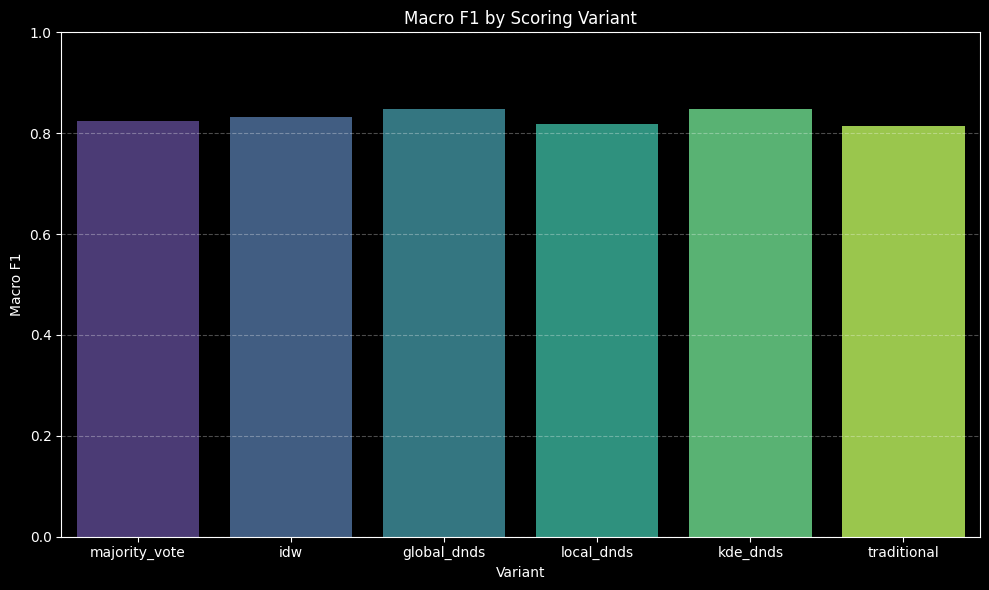

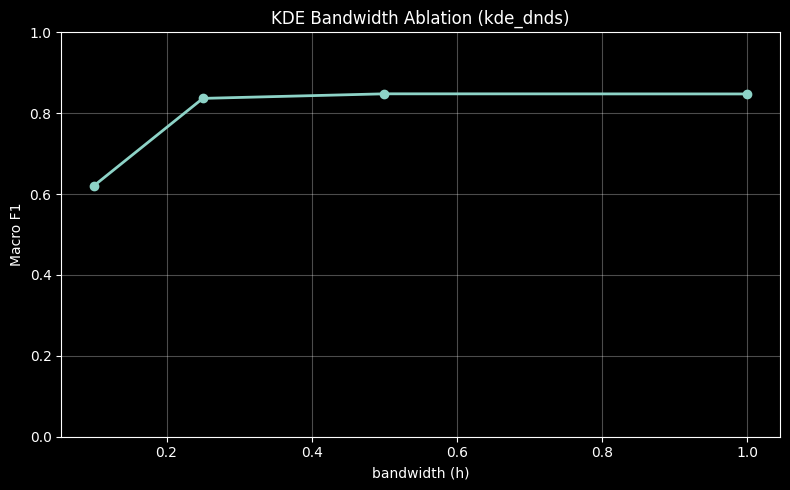

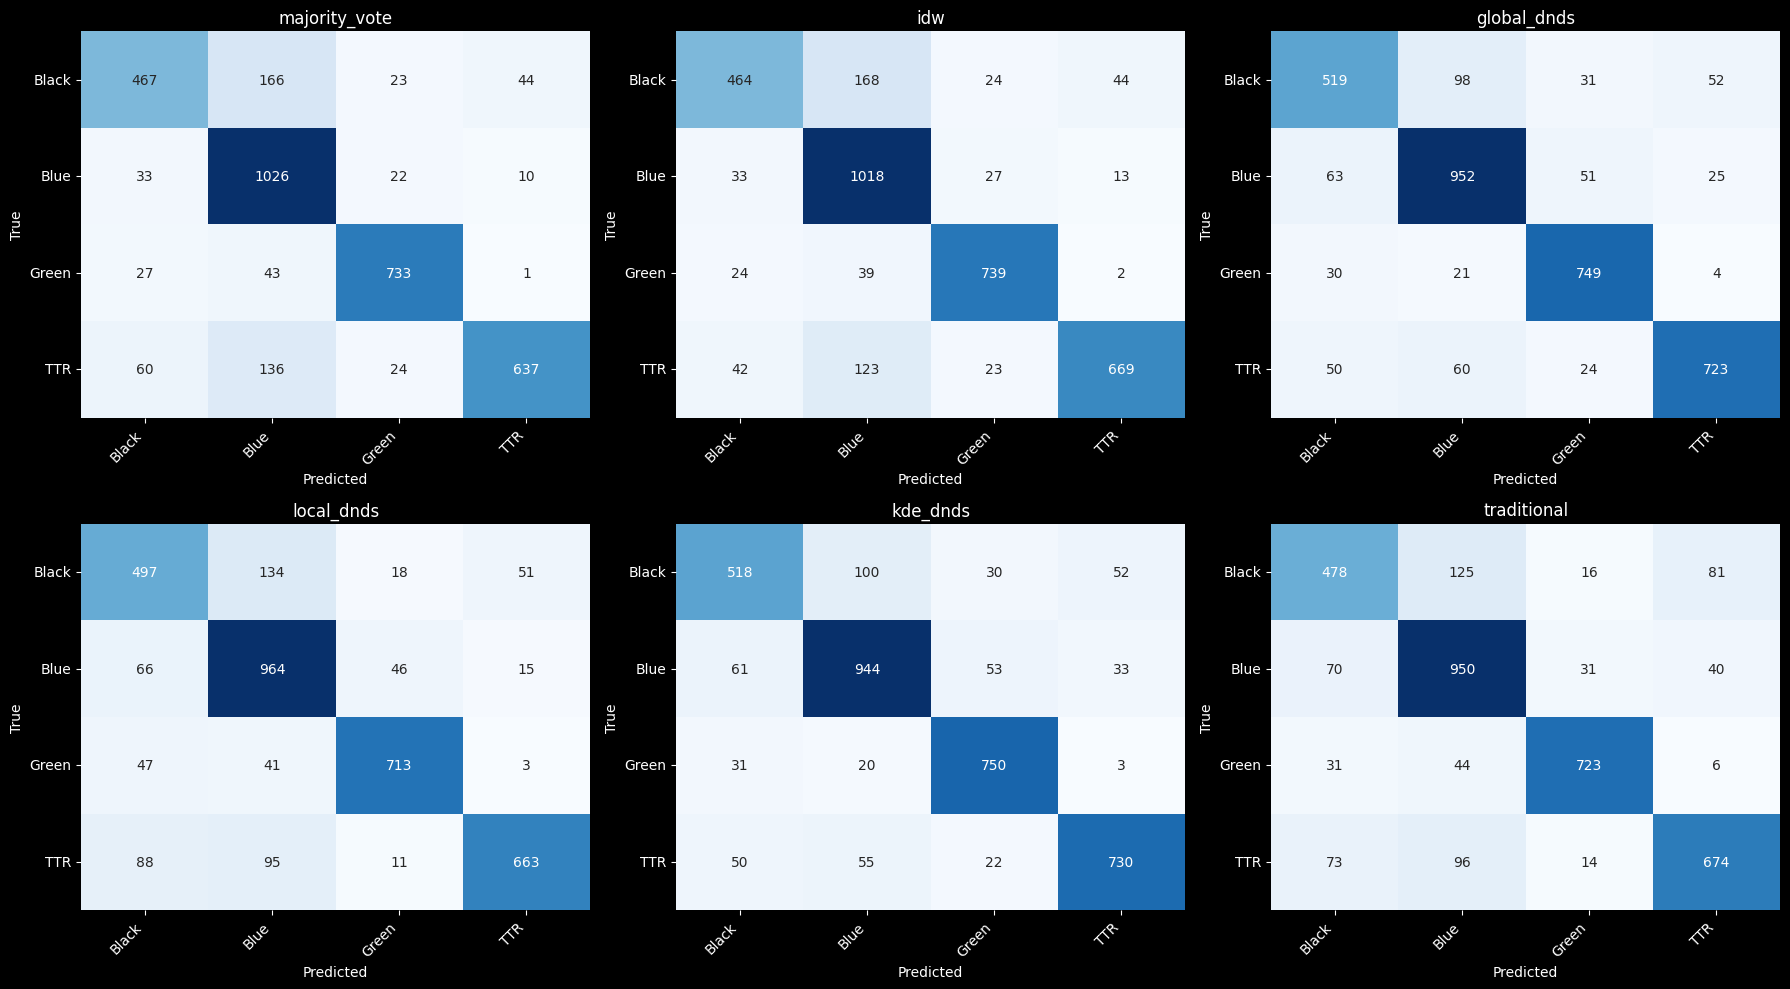

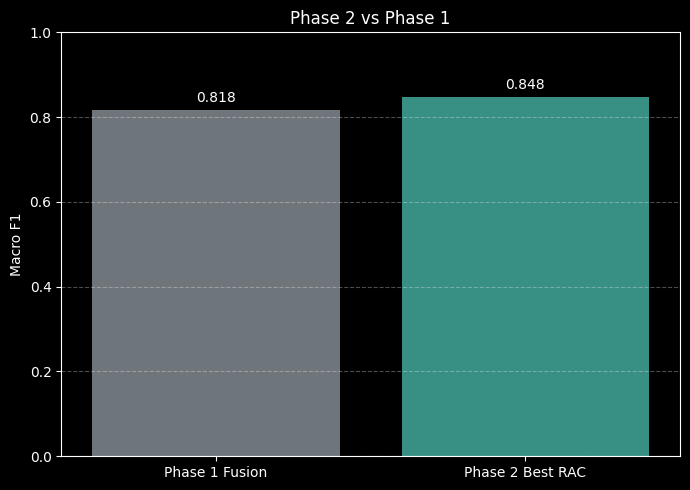

In [5]:
save_results(results, str(RESULTS_PATH))
save_metrics_summary_csv(results["variants"], str(METRICS_CSV_PATH))
save_predictions_csv(results["variants"], str(PREDICTIONS_CSV_PATH))

plot_scoring_comparison(results, str(FIGURES_DIR / "scoring_comparison_no_alpha.png"))
plot_kde_bandwidth_ablation(
    results["kde_bandwidth"], str(FIGURES_DIR / "kde_bandwidth_ablation_no_alpha.png")
)
plot_confusion_matrices(
    results,
    CONFIG["class_names"],
    str(FIGURES_DIR / "confusion_matrices_phase2_no_alpha.png"),
    variants=[
        "majority_vote",
        "idw",
        "global_dnds",
        "local_dnds",
        "kde_dnds",
        "traditional",
    ],
)
phase1_macro_f1 = 0.8177
best_phase2 = max(
    v.get("macro_f1", 0.0) for k, v in results["variants"].items() if k != "traditional"
)
plot_phase2_vs_phase1(
    best_phase2, phase1_macro_f1, str(FIGURES_DIR / "phase2_vs_phase1_no_alpha.png")
)

print(f"Saved JSON results: {RESULTS_PATH}")
print(f"Saved CSV metrics: {METRICS_CSV_PATH}")
print(f"Saved CSV predictions: {PREDICTIONS_CSV_PATH}")

### Cell 7 - Persist Results and Create Figures
Purpose: save no-alpha metrics/predictions and regenerate visual summaries for direct comparison against tuned and phase-1 baselines.

### Cell 8 - Final Run Summary
Purpose: print a compact report of final metrics and fixed-alpha settings so the notebook output can be cited directly in analysis and write-up.

In [6]:
print("=" * 60)
print("PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - RESULTS SUMMARY")
print("=" * 60)
print("Variant              | Accuracy | Macro F1 | TTR F1 | Latency")
print("---------------------|----------|----------|--------|--------")
for name, metrics in results["variants"].items():
    ttr_f1 = metrics.get("per_class_f1", {}).get("TTR", 0.0)
    print(
        f"{name:<20} | {metrics['accuracy']*100:6.2f}% | {metrics['macro_f1']:.4f} | {ttr_f1:.4f} | {metrics['latency_ms_per_sample']:.2f} ms"
    )
print("=" * 60)
print(f"Alpha tuning: disabled (fixed alpha={results['best_alpha_local']})")
print(f"Best local DNDS K_density: {results['best_k_density_local']}")
print(f"Best KDE bandwidth (h): {results['best_kde_bandwidth']}")

PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - RESULTS SUMMARY
Variant              | Accuracy | Macro F1 | TTR F1 | Latency
---------------------|----------|----------|--------|--------
majority_vote        |  82.94% | 0.8236 | 0.8225 | 84.57 ms
idw                  |  83.72% | 0.8319 | 0.8442 | 88.50 ms
global_dnds          |  85.25% | 0.8481 | 0.8706 | 358.89 ms
local_dnds           |  82.18% | 0.8176 | 0.8345 | 85.25 ms
kde_dnds             |  85.23% | 0.8480 | 0.8716 | 1076.23 ms
traditional          |  81.84% | 0.8137 | 0.8130 | 43.05 ms
Alpha tuning: disabled (fixed alpha=0.5)
Best local DNDS K_density: 10
Best KDE bandwidth (h): 0.5
